# Chip Timing Markers & TTP Timeline Analysis

For each experiment under the `*_nc_subtract` dataset tree, builds one combined view of:

1. `idx_start`, `idx_settled`, `idx_end`, `idx_active` — read directly off the `Well`
   objects returned by `chip_v6_utils.load_and_preprocess_v6` (the titan_v6 raw-chip
   conversion `01_curve_preprocessing_v6.py` uses).
2. The timestamp corresponding to each of those indices (Section 3 explains why that's
   `well.time_npr[idx]`, not `well.time[idx]`).
3. `max_significant_index` — the NC-subtract truncation point, computed exactly the way
   `01_curve_preprocessing_v6.py --nc_subtract` computes it — plus its timestamp.
4. TTP (Time-To-Positive), computed from the already-processed `curve_for_training.joblib`,
   the same way the existing kinetic-feature notebook (`new_chip_analysis.ipynb`) does it.

Section 6 puts all five markers on one shared, zero-referenced timeline, in the order
`idx_start -> idx_settled -> max_significant_index (if any) -> TTP -> idx_end`.


In [1]:
%matplotlib inline
import os
import sys
import importlib
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

try:
    notebook_dir = os.path.dirname(globals().get('__vsc_ipynb_file__', os.getcwd()))
    os.chdir(notebook_dir)
except Exception:
    pass

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.join(os.getcwd(), 'utils', '01_curve_preprocessing'))

%load_ext autoreload
%autoreload 2

import config
import sigmoid_fitting as sp
from chip_v6_utils import load_and_preprocess_v6

# Reused (not copied) so Section 4's max_significant_index logic stays byte-for-byte
# identical to what 01_curve_preprocessing_v6.py --nc_subtract actually runs.
prep01 = importlib.import_module("01_curve_preprocessing_v6")

print("Working directory:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

Working directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main


## 1. Choose experiments to analyze

`config.get_label_mappings` distinguishes nc_subtract-treated data by checking
`Path(exp_path).parent.name.endswith("nc_subtract")` — i.e. the dataset *tree* you load
from, not a suffix on each experiment folder's own name (the per-experiment folders
under `POC_DDM_multi_nc_subtract` are named identically to their `POC_DDM_multi`
counterparts).

The two trees are **not interchangeable**, though (verified directly by listing both):
`POC_DDM_multi_nc_subtract` holds only *derived* outputs (`curve_for_training.joblib`,
model results, visualizations) — no raw `.bin` captures at all. `load_and_preprocess_v6`
(Sections 2-4, raw `Well` objects) needs the raw tree, `POC_DDM_multi`; Section 5's TTP
needs the nc_subtract tree's `curve_for_training.joblib` specifically, since that's the
one actually written with `--nc_subtract` truncation applied. Both trees share identical
experiment folder names, so one experiment-name list drives both.

Loading raw Wells via `load_and_preprocess_v6` is the slow step (~10-20s per
experiment), so `N_EXPERIMENTS` keeps Sections 2-4 & 6 to a handful — widen the slice to
cover more. Section 5 (TTP) is cheap (joblib-based) and runs over every experiment
regardless.


In [16]:
RAW_ROOT = Path(config.MULTI_EXP_FOLDER)            # has the raw .bin captures
NC_SUBTRACT_ROOT = Path(config.MULTI_EXP_FOLDER + "_nc_subtract")  # derived-only; nc_subtract-truncated joblibs
assert RAW_ROOT.exists(), f"Not found: {RAW_ROOT}"
assert NC_SUBTRACT_ROOT.exists(), f"Not found: {NC_SUBTRACT_ROOT}"

all_exp_names = sorted([
    name for name in os.listdir(NC_SUBTRACT_ROOT)
    if (NC_SUBTRACT_ROOT / name).is_dir() and name not in config.EXCLUDED_FOLDERS
])
print(f"[*] Found {len(all_exp_names)} candidate experiment folder(s):")
for n in all_exp_names:
    print("   -", n)

# Drop known one-off test runs. (The pasted snippet this notebook is based on tried to do
# this via Experiment.str.endswith('test_05_nc_subtract')/'nc_subtract' -- that never
# matches current folder names, since the suffix lives on the parent tree, not here.)
EXCLUDE_SUBSTRINGS = ["test_05"]
exp_names = [n for n in all_exp_names if not any(s in n for s in EXCLUDE_SUBSTRINGS)]

N_EXPERIMENTS = 2  # raise this to cover more -- each one costs ~10-20s to load raw Wells
exp_names_subset = exp_names[:]
exp_paths_subset = [RAW_ROOT / n for n in exp_names_subset]  # raw tree, for load_and_preprocess_v6

print(f"\n[*] Using {len(exp_names_subset)} experiment(s) for Sections 2-4 & 6:", exp_names_subset)
print(f"[*] All {len(exp_names)} experiment(s) (excluding test runs) will be used for Section 5 (TTP).")
print("[*] Note: a small number of folders may still lack usable raw binaries -- Section 2's "
      "loop below skips and warns on any that fail to load via load_and_preprocess_v6, rather "
      "than aborting the whole notebook.")


[*] Found 7 candidate experiment folder(s):
   - D20260320_E00_C00_F4500KHz_U_Elena_steap_cv
   - D20260522_E00_C00_F4500KHz_U_manifold_test_05
   - D20260608_E00_C00_F4500KHz_U_norm_temp_04
   - D20260609_E00_C00_F4500KHz_U_norm_temp_read_06
   - D20260609_E00_C00_F4500KHz_U_norm_temp_read_07
   - D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08
   - D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01

[*] Using 6 experiment(s) for Sections 2-4 & 6: ['D20260320_E00_C00_F4500KHz_U_Elena_steap_cv', 'D20260608_E00_C00_F4500KHz_U_norm_temp_04', 'D20260609_E00_C00_F4500KHz_U_norm_temp_read_06', 'D20260609_E00_C00_F4500KHz_U_norm_temp_read_07', 'D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08', 'D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01']
[*] All 6 experiment(s) (excluding test runs) will be used for Section 5 (TTP).
[*] Note: a small number of folders may still lack usable raw binaries -- Section 2's loop below skips and warns on any that fail to load via load_and_preprocess_v6,

## 2. Raw Wells via `load_and_preprocess_v6`: `idx_start`, `idx_settled`, `idx_end`, `idx_active`

`01_curve_preprocessing_v6.py` itself treats `well0 = all_exp_data[0].wells_list[0]` as
representative for an experiment's timing markers (see `save_experiment_data_restructured`,
where these get written into the `"idxs"` key of `curve_for_training.joblib`) — they come
from acquisition hardware/firmware timing, not from any individual well's signal, so
they're shared across all wells/vref-groups in the same experiment.


In [17]:
markers_records = []
loaded_exp_data = {}  # cache so Sections 3/4/6 don't reload raw data

for exp_path in exp_paths_subset:
    exp_name = exp_path.name
    print(f"[*] Loading raw Wells for: {exp_name} ...")
    try:
        all_exp_data = load_and_preprocess_v6(
            exp_path=exp_path, n_wells=config.N_WELLS, n_a_type=config.N_A_TYPE, vref_ref_idx="all",
        )
        well0 = all_exp_data[0].wells_list[0]
    except Exception as e:
        print(f"    [!] Skipping {exp_name} -- failed to load raw Wells ({e!r}). "
              f"Likely a CV/summary folder without raw binaries rather than a real experiment.")
        continue

    loaded_exp_data[exp_name] = all_exp_data
    markers_records.append({
        "Experiment": exp_name,
        "idx_start": int(well0.idx_start),
        "idx_settled": int(well0.idx_settled),
        "idx_end": int(well0.idx_end),
        "n_active_pixels": int(np.sum(well0.idx_active)),
        "n_total_pixels": int(len(well0.idx_active)),
        "time_npr_len": len(well0.time_npr),
    })

markers_df = pd.DataFrame(markers_records)
exp_names_subset = list(loaded_exp_data.keys())  # keep only experiments that actually loaded
markers_df


[*] Loading raw Wells for: D20260320_E00_C00_F4500KHz_U_Elena_steap_cv ...
[INFO] D20260320_E00_C00_F4500KHz_U_Elena_steap_cv: found 1 readout file(s). Processing...
Loaded vref sweep from 20260320T105348.52_vref_sweep.bin: n_vrefs=2
[INFO] Slice 1/2: Elena_steap_cv__vref_idx=0_vref=1810
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi/D20260320_E00_C00_F4500KHz_U_Elena_steap_cv 
VREF PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi/D20260320_E00_C00_F4500KHz_U_Elena_steap_cv/20260320T105348.52_vref_sweep.bin 
Load vref... 
Loaded vref list: n_vrefs=2, first=1810, last=2610
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi/D20260320_E00_C00_F4500KHz_U_Elena_steap_cv 
READOUT PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi/D20260320_E00_C00_F4500KHz_U_Elena_steap_cv/20260320T105439.73_readout_time.bin 
Load data... 
(290, 204, 2, 630)
Time vector: n=630, median_dt=4s, duration≈41.03min
(59160,)
new gain shape  (59160,)
(290, 204, 2, 630)
Data load

,Experiment,idx_start,idx_settled,idx_end,n_active_pixels,n_total_pixels,time_npr_len
0,D20260320_E00_C00_F4500KHz_U_Elena_steap_cv,15,23,629,200,5916,630
1,D20260608_E00_C00_F4500KHz_U_norm_temp_04,16,22,884,1937,5916,885
2,D20260609_E00_C00_F4500KHz_U_norm_temp_read_06,16,24,896,1951,5916,897
3,D20260609_E00_C00_F4500KHz_U_norm_temp_read_07,17,22,912,1825,5916,913
4,D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08,18,23,899,1898,5916,900
5,D20260611_E00_C00_F4500KHz_U_lambda_test_manif...,16,24,896,1781,5916,897


## 3. Corresponding timestamp for each idx

`idx_start`/`idx_settled`/`idx_end` are indices into `well.time_npr` (the raw,
full-length per-frame clock) — **not** `well.time`. `well.time` is itself a derived
property (`titan_v6/Well.py`):

```python
@property
def time(self):
    return self.time_npr[self.idx_settled:self.idx_end] - self.time_npr[self.idx_start]
```

so it is already sliced to `[idx_settled:idx_end]` and zeroed to `idx_start`'s
timestamp — indexing it with `idx_end` itself is out of bounds (verified directly: for
one real experiment, `idx_end=884` but `len(well.time)=862`). `time_npr[idx]` is
therefore the correct lookup for these three markers. `idx_active` indexes pixels, not
time, so it has no associated timestamp.


In [18]:
def add_idx_timestamps(markers_df, loaded_exp_data):
    out = markers_df.copy()
    for col in ["idx_start", "idx_settled", "idx_end"]:
        out[f"t_{col}"] = out.apply(
            lambda row: loaded_exp_data[row["Experiment"]][0].wells_list[0].time_npr[row[col]],
            axis=1,
        )
    return out

markers_df = add_idx_timestamps(markers_df, loaded_exp_data)
markers_df[["Experiment", "idx_start", "t_idx_start", "idx_settled", "t_idx_settled", "idx_end", "t_idx_end"]]


,Experiment,idx_start,t_idx_start,idx_settled,t_idx_settled,idx_end,t_idx_end
0,D20260320_E00_C00_F4500KHz_U_Elena_steap_cv,15,59.0,23,90.0,629,2462.0
1,D20260608_E00_C00_F4500KHz_U_norm_temp_04,16,43.0,22,60.0,884,2446.0
2,D20260609_E00_C00_F4500KHz_U_norm_temp_read_06,16,44.0,24,65.0,896,2445.0
3,D20260609_E00_C00_F4500KHz_U_norm_temp_read_07,17,45.0,22,58.0,912,2447.0
4,D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08,18,49.0,23,62.0,899,2453.0
5,D20260611_E00_C00_F4500KHz_U_lambda_test_manif...,16,43.0,24,64.0,896,2444.0


## 4. `max_significant_index` (NC-subtract truncation logic) + its timestamp

Exactly replicates the truncation-index calculation `01_curve_preprocessing_v6.py
--nc_subtract` runs: per-curve derivative-minimum index, voted across all curves in the
experiment, kept only if it recurs in more than 1/3 of them. `None` means no such
common transient was found (truncation is skipped for that experiment).

The raw value `max_significant_index` is itself an index into `well.time` (`reconstruct_data`
builds `X_time` from `well0.time`), which is `time_npr[idx_settled:idx_end] -
time_npr[idx_start]` — so position `k` there is raw `time_npr` index `idx_settled + k`.
To put it on the same `idx_*` axis as Sections 2-3 (all `time_npr`-indexed):

```
max_significant_index_norm = max_significant_index + idx_settled
t_max_significant_index     = time_npr[max_significant_index_norm]
```


In [19]:
def compute_max_significant_index(all_exp_data):
    """Mirrors 01_curve_preprocessing_v6.py's --nc_subtract truncation-index logic exactly."""
    X_time, Y_well, X_2d_bs_active = prep01.reconstruct_data(all_exp_data, attr_str="well_2d_bs_active")
    ori_curve_dydx = np.array(prep01.get_derivatives(X_2d_bs_active, X_time))
    min_indices = np.argmin(ori_curve_dydx, axis=1)

    unique_indices, counts = np.unique(min_indices, return_counts=True)
    threshold = len(ori_curve_dydx) / 3
    significant_indices = unique_indices[counts > threshold]

    max_significant_index = int(np.max(significant_indices)) if len(significant_indices) > 0 else None
    return max_significant_index

msi_records = []
for exp_name, all_exp_data in loaded_exp_data.items():
    print(f"[*] Computing max_significant_index for: {exp_name} ...")
    msi = compute_max_significant_index(all_exp_data)
    time_npr = loaded_exp_data[exp_name][0].wells_list[0].time_npr
    idx_settled = int(markers_df.loc[markers_df["Experiment"] == exp_name, "idx_settled"].iloc[0])

    if msi is not None:
        msi_norm = msi + idx_settled
        t_msi = float(time_npr[msi_norm])
    else:
        msi_norm, t_msi = None, np.nan

    msi_records.append({
        "Experiment": exp_name,
        "max_significant_index": msi,
        "max_significant_index_norm": msi_norm,
        "t_max_significant_index": t_msi,
    })
    print(f"    -> max_significant_index = {msi}, _norm = {msi_norm}"
          + (f" (t = {t_msi:.2f})" if msi is not None else " (none found)"))

msi_df = pd.DataFrame(msi_records)
markers_df = markers_df.merge(msi_df, on="Experiment", how="left")
markers_df


[*] Computing max_significant_index for: D20260320_E00_C00_F4500KHz_U_Elena_steap_cv ...
    -> max_significant_index = 3, _norm = 26 (t = 101.00)
[*] Computing max_significant_index for: D20260608_E00_C00_F4500KHz_U_norm_temp_04 ...
    -> max_significant_index = 5, _norm = 27 (t = 73.00)
[*] Computing max_significant_index for: D20260609_E00_C00_F4500KHz_U_norm_temp_read_06 ...
    -> max_significant_index = 10, _norm = 34 (t = 93.00)
[*] Computing max_significant_index for: D20260609_E00_C00_F4500KHz_U_norm_temp_read_07 ...
    -> max_significant_index = 8, _norm = 30 (t = 79.00)
[*] Computing max_significant_index for: D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08 ...
    -> max_significant_index = 8, _norm = 31 (t = 84.00)
[*] Computing max_significant_index for: D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01 ...
    -> max_significant_index = 7, _norm = 31 (t = 83.00)


,Experiment,idx_start,idx_settled,idx_end,n_active_pixels,n_total_pixels,time_npr_len,t_idx_start,t_idx_settled,t_idx_end,max_significant_index,max_significant_index_norm,t_max_significant_index
0,D20260320_E00_C00_F4500KHz_U_Elena_steap_cv,15,23,629,200,5916,630,59.0,90.0,2462.0,3,26,101.0
1,D20260608_E00_C00_F4500KHz_U_norm_temp_04,16,22,884,1937,5916,885,43.0,60.0,2446.0,5,27,73.0
2,D20260609_E00_C00_F4500KHz_U_norm_temp_read_06,16,24,896,1951,5916,897,44.0,65.0,2445.0,10,34,93.0
3,D20260609_E00_C00_F4500KHz_U_norm_temp_read_07,17,22,912,1825,5916,913,45.0,58.0,2447.0,8,30,79.0
4,D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08,18,23,899,1898,5916,900,49.0,62.0,2453.0,8,31,84.0
5,D20260611_E00_C00_F4500KHz_U_lambda_test_manif...,16,24,896,1781,5916,897,43.0,64.0,2444.0,7,31,83.0


## 5. TTP (Time-To-Positive) from the processed pipeline

Reuses the pixel/well-level kinetic-feature extraction already built and validated in
`new_chip_analysis.ipynb` (copied here so this notebook is self-contained), run on every
experiment in the nc_subtract tree — this works off the already-saved
`curve_for_training.joblib`, no raw reload needed, so it's cheap regardless of
`N_EXPERIMENTS` above.

Note: the original snippet this is based on filtered plots to `target_label='Target'`,
but `'Target'` is only one experiment group's label convention (others use `'S'/'C'` or
`'Conc-01'/'Conc-02'`, see `config.LABEL_MAPPINGS`) — so below this is generalized to
"all labels" / "non-NC labels" instead of a hardcoded string.


In [20]:
def process_all_curves_pixel_level(exp_folders):
    pixel_records = []
    mean_curve_records = []

    for exp_path in exp_folders:
        exp_path = Path(exp_path)
        exp_name = exp_path.name

        data_path = exp_path / config.TRAINING_DATA_PATH
        if not data_path.exists():
            continue

        print(f"Processing: {exp_name} ...")
        data = joblib.load(data_path)

        ori_curves = data["dataset"][0]
        df_std = data["kinetic_features"][0].copy()
        y_well = np.array(data["Y_well"])
        exp_timestamps = data["timestamps"]

        if hasattr(config, "LABEL_MAPPINGS") and exp_name in config.LABEL_MAPPINGS:
            mapping = config.LABEL_MAPPINGS[exp_name]
            y_label = np.array([mapping.get(w, w) for w in y_well])
        else:
            y_label = np.array(y_well)

        unique_wells = np.unique(y_well)

        df_std['Experiment'] = exp_name
        df_std['Well_ID'] = y_well
        df_std['Label'] = y_label
        pixel_records.append(df_std)

        for well_id in unique_wells:
            mask = (y_well == well_id)
            label = y_label[mask][0]
            mean_std = np.mean(ori_curves[mask], axis=0)
            mean_curve_records.append({
                'Experiment': exp_name,
                'Well_ID': well_id,
                'Label': label,
                'Mean_Curve': mean_std,
                'Timestamps': exp_timestamps,
            })

    pixel_features_df = pd.concat(pixel_records, ignore_index=True)
    well_mean_curves_df = pd.DataFrame(mean_curve_records)
    return pixel_features_df, well_mean_curves_df


def apply_ct_multiplier(df):
    """Multiplies 'Ct' by 10 for experiments 06, 07, and 08 in place."""
    if 'Ct' in df.columns:
        mask = df['Experiment'].str.contains('06|07|08', na=False)
        df.loc[mask, 'Ct'] *= 10
    return df


def aggregate_features_to_well(pixel_features_df):
    """Aggregates the pixel-level features to the well-level via mean."""
    return pixel_features_df.groupby(['Experiment', 'Well_ID', 'Label'], as_index=False).mean(numeric_only=True)


def extract_features_from_mean_curves(mean_curves_df):
    agg_records = []
    for _, row in mean_curves_df.iterrows():
        curve = row['Mean_Curve']
        ts = row['Timestamps']
        try:
            features = sp.extract_kinetic_parameters_original(ts, curve)
        except Exception as e:
            print(f"Extraction failed for {row['Experiment']} Well {row['Well_ID']}: {e}")
            features = {}
        record = {'Experiment': row['Experiment'], 'Well_ID': row['Well_ID'], 'Label': row['Label'], 'Mean_Curve': curve}
        record.update(features)
        agg_records.append(record)
    return pd.DataFrame(agg_records)


def plot_kinetic_feature_across_datasets(well_agg_df, feature_name, target_label=None, title_suffix=None):
    """Plots a histogram/bar chart comparing a specific kinetic feature across different datasets."""
    import seaborn as sns
    import warnings

    plot_df = well_agg_df.copy()
    if target_label is not None:
        plot_df = plot_df[plot_df['Label'] == target_label].copy()
        label_title = f" for Label: '{target_label}'"
    else:
        label_title = " (All Labels)"

    plot_df = plot_df.dropna(subset=[feature_name])
    if plot_df.empty:
        print(f"No data for feature: '{feature_name}'")
        return

    plt.figure(figsize=(14, 8))
    sns.barplot(data=plot_df, x='Experiment', y=feature_name, capsize=.1, errcolor='gray', color='skyblue')
    if len(plot_df) > len(plot_df['Experiment'].unique()):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sns.swarmplot(data=plot_df, x='Experiment', y=feature_name, color='black', alpha=0.6, size=6)

    plt.title(f"{title_suffix or ''}{label_title}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Experiment (Dataset)", fontsize=11, fontweight='bold')
    plt.ylabel(feature_name, fontsize=11, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [21]:
ttp_exp_paths = [NC_SUBTRACT_ROOT / n for n in exp_names]  # all (non-test) nc_subtract-tree experiments

pixel_features_df, well_mean_curves_df = process_all_curves_pixel_level(ttp_exp_paths)
pixel_features_df = apply_ct_multiplier(pixel_features_df)

well_agg_df = extract_features_from_mean_curves(well_mean_curves_df)
well_agg_df = apply_ct_multiplier(well_agg_df)

well_agg_df_mean_all = aggregate_features_to_well(pixel_features_df)
well_agg_df_filtered = well_agg_df_mean_all.copy()  # already scoped to the nc_subtract tree via ttp_exp_paths

timestamps_map = well_mean_curves_df.groupby('Experiment')['Timestamps'].first().to_dict()

def get_exact_time(row, idx_col_name):
    """TTP as originally computed -- duration from the start of the saved (possibly
    truncated) curve. Kept as-is; Section 6 converts this into a time_npr-absolute index."""
    exp = row['Experiment']
    idx = row[idx_col_name]
    if pd.isna(idx):
        return np.nan
    idx = int(idx)
    ts_array = timestamps_map.get(exp)
    if ts_array is not None and 0 <= idx < len(ts_array):
        return ts_array[idx] - ts_array[0]
    return np.nan

well_agg_df_filtered['TTP'] = well_agg_df_filtered.apply(lambda row: get_exact_time(row, 'ct_idx'), axis=1)

well_agg_df_filtered[['Experiment', 'Well_ID', 'Label', 'ct_idx', 'TTP']]


Processing: D20260608_E00_C00_F4500KHz_U_norm_temp_04 ...
Processing: D20260609_E00_C00_F4500KHz_U_norm_temp_read_06 ...
Processing: D20260609_E00_C00_F4500KHz_U_norm_temp_read_07 ...
Processing: D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08 ...
Processing: D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01 ...


,Experiment,Well_ID,Label,ct_idx,TTP
0,D20260608_E00_C00_F4500KHz_U_norm_temp_04,0,Target,220.901394,607.0
1,D20260608_E00_C00_F4500KHz_U_norm_temp_04,1,NC,331.979062,914.0
2,D20260608_E00_C00_F4500KHz_U_norm_temp_04,2,NC,383.751932,1058.0
3,D20260608_E00_C00_F4500KHz_U_norm_temp_04,3,Target,203.644992,560.0
4,D20260608_E00_C00_F4500KHz_U_norm_temp_04,4,Target,185.214758,510.0
5,D20260608_E00_C00_F4500KHz_U_norm_temp_04,5,NC,313.445831,864.0
6,D20260608_E00_C00_F4500KHz_U_norm_temp_04,6,NC,114.733748,314.0
7,D20260608_E00_C00_F4500KHz_U_norm_temp_04,7,Target,185.326861,510.0
8,D20260608_E00_C00_F4500KHz_U_norm_temp_04,8,Target,131.206402,361.0
9,D20260608_E00_C00_F4500KHz_U_norm_temp_04,9,NC,85.104178,233.0


In [52]:
# target_features = ['Ct', 'ct_idx', 'TTP', 'Cs']

# for feature in target_features:
#     plot_kinetic_feature_across_datasets(
#         well_agg_df=well_agg_df_filtered,
#         feature_name=feature,
#         target_label=None,  # all labels -- 'Target' isn't universal across experiments, see note above
#         title_suffix=f"Comparison of '{feature}' Across Datasets",
#     )


## 6. Unified timeline: idx_start -> idx_settled -> max_significant_index_norm -> idx_TTP_norm -> idx_end

Every marker is expressed as an index into `time_npr` (`idx_*_norm`), then converted to
a timestamp via `time_npr[idx_*_norm]` — no separate zeroing/reconciliation needed since
they're all on the same axis already:

- `idx_start`, `idx_settled`, `idx_end`, `max_significant_index_norm` — computed in
  Sections 2-4.
- `idx_TTP_norm`: TTP (`ct_idx`) is a position in the *saved* (possibly truncated)
  curve, whose own index 0 sits at `time_npr` index `max_significant_index_norm + 1`
  when truncation happened (the truncation slice is `well.time[max_significant_index+1:]`),
  or at `idx_settled` otherwise:

```
anchor_norm   = max_significant_index_norm + 1   if max_significant_index is not None
              else idx_settled
idx_TTP_norm  = anchor_norm + ct_idx
```

TTP is summarized per experiment as the mean `ct_idx`/`TTP` across non-NC wells (the
per-experiment label conventions differ, so this avoids hardcoding one label string).


In [23]:
def unified_timeline_markers(markers_row, ct_idx_value):
    idx_settled = int(markers_row["idx_settled"])
    msi = markers_row["max_significant_index"]
    msi_norm = markers_row["max_significant_index_norm"]

    if pd.notna(msi):
        anchor_norm = int(msi_norm) + 1
    else:
        anchor_norm = idx_settled

    idx_ttp_norm = (anchor_norm + int(ct_idx_value)) if pd.notna(ct_idx_value) else np.nan

    return {
        "idx_start": int(markers_row["idx_start"]),
        "idx_settled": idx_settled,
        "max_significant_index_norm": msi_norm,
        "idx_TTP_norm": idx_ttp_norm,
        "idx_end": int(markers_row["idx_end"]),
    }


In [129]:
%matplotlib inline

sequence = ["idx_start", "idx_settled", "max_significant_index_norm", "idx_TTP_norm", "idx_end"]

# --- Experiment-level anchors (idx_start/idx_settled/max_significant_index_norm/idx_end + anchor_norm for TTP) ---
anchor_df = markers_df[["Experiment", "idx_start", "idx_settled", "max_significant_index", "max_significant_index_norm", "idx_end"]].copy()
anchor_df["anchor_norm"] = np.where(
    anchor_df["max_significant_index"].notna(),
    anchor_df["max_significant_index_norm"] + 1,
    anchor_df["idx_settled"],
)

# --- Per-well table: join anchors onto every well's own ct_idx/TTP ---
per_well_df = well_agg_df_filtered[["Experiment", "Well_ID", "Label", "ct_idx", "TTP"]].merge(
    anchor_df, on="Experiment", how="left"
)
per_well_df["idx_TTP_norm"] = per_well_df["anchor_norm"] + per_well_df["ct_idx"]

def add_timestamps(df, idx_cols):
    df = df.copy()
    for exp_name in df["Experiment"].unique():
        time_npr = loaded_exp_data[exp_name][0].wells_list[0].time_npr
        mask = df["Experiment"] == exp_name
        for key in idx_cols:
            df.loc[mask, f"t_{key}"] = df.loc[mask, key].apply(
                lambda idx: float(time_npr[int(idx)]) if pd.notna(idx) else np.nan
            )
    return df

per_well_df = add_timestamps(per_well_df, sequence)
per_well_df = per_well_df[per_well_df.Label == 'Target'].reset_index()

In [130]:
summary_df = (
    per_well_df[~per_well_df["Label"].str.startswith("NC")]
    .groupby("Experiment", as_index=False)["idx_TTP_norm"].mean()
    .merge(anchor_df[["Experiment", "idx_start", "idx_settled", "max_significant_index_norm", "idx_end"]], on="Experiment")
)
summary_df = add_timestamps(summary_df, sequence)

In [108]:
# import math

# sequence = ["idx_start", "idx_settled", "max_significant_index_norm", "idx_TTP_norm", "idx_end"]
# colors = {
#     "idx_start": "tab:blue", "idx_settled": "tab:green", "max_significant_index_norm": "tab:orange",
#     "idx_TTP_norm": "tab:red", "idx_end": "tab:purple",
# }

# for exp_name, exp_group in per_well_df[per_well_df.Experiment == np.unique(per_well_df.Experiment)[-1]].groupby("Experiment"):
#     well_ids = exp_group["Well_ID"].unique()
#     n = len(well_ids)
#     cols = 1
#     rows = math.ceil(n / cols)

#     fig, axes = plt.subplots(rows, cols, figsize=(20 * cols, 4 * rows), squeeze=False)

#     for i, well_id in enumerate(well_ids):
#         ax = axes[i // cols, i % cols]
#         well = loaded_exp_data[exp_name][0].wells_list[well_id]
#         x = well.time_npr
#         y = np.mean(well.well_2d_npr, axis=1)

#         ax.plot(x, y, color="black", lw=1.5)

#         row = exp_group[exp_group["Well_ID"] == well_id].iloc[0]
#         for key in sequence:
#             idx = row[key]
#             if pd.isna(idx):
#                 continue
#             idx = int(idx)
#             t = row[f"t_{key}"]
#             if 0 <= idx < len(x):
#                 ax.axvline(x[idx], color=colors[key], linestyle="--", lw=1.5,
#                            label=f"{key} ({t:.1f}s)")

#         ax.set_title(f"Well {well_id}", fontsize=10, fontweight="bold")
#         ax.set_xlabel("time_npr")
#         ax.set_ylabel("well_temp_mean_then_lin")
#         ax.legend(fontsize=7)

#     for j in range(n, rows * cols):
#         axes[j // cols, j % cols].axis("off")

#     fig.suptitle(f"{exp_name}", fontsize=14, fontweight="bold", y=1.02)
#     plt.tight_layout()
#     plt.show()

In [107]:
# import math

# sequence = ["idx_start", "idx_settled", "max_significant_index_norm", "idx_TTP_norm", "idx_end"]
# colors = {
#     "idx_start": "tab:blue", "idx_settled": "tab:green", "max_significant_index_norm": "tab:orange",
#     "idx_TTP_norm": "tab:red", "idx_end": "tab:purple",
# }

# for exp_name, exp_group in per_well_df[per_well_df.Experiment == np.unique(per_well_df.Experiment)[-1]].groupby("Experiment"):
#     well_ids = exp_group["Well_ID"].unique()
#     n = len(well_ids)
#     cols = 1
#     rows = math.ceil(n / cols)

#     fig, axes = plt.subplots(rows, cols, figsize=(20 * cols, 4 * rows), squeeze=False)

#     for i, well_id in enumerate(well_ids):
#         ax = axes[i // cols, i % cols]
#         well = loaded_exp_data[exp_name][0].wells_list[well_id]
#         x = well.time_npr
#         y = well.well_temp_mean_then_lin

#         ax.plot(x, y, color="black", lw=1.5)

#         row = exp_group[exp_group["Well_ID"] == well_id].iloc[0]
#         for key in sequence:
#             idx = row[key]
#             if pd.isna(idx):
#                 continue
#             idx = int(idx)
#             t = row[f"t_{key}"]
#             if 0 <= idx < len(x):
#                 ax.axvline(x[idx], color=colors[key], linestyle="--", lw=1.5,
#                            label=f"{key} ({t:.1f}s)")

#         ax.set_title(f"Well {well_id}", fontsize=10, fontweight="bold")
#         ax.set_xlabel("time_npr")
#         ax.set_ylabel("well_temp_mean_then_lin")
#         ax.legend(fontsize=7)

#     for j in range(n, rows * cols):
#         axes[j // cols, j % cols].axis("off")

#     fig.suptitle(f"{exp_name}", fontsize=14, fontweight="bold", y=1.02)
#     plt.tight_layout()
#     plt.show()

In [131]:
per_well_df = per_well_df.rename({'max_significant_index_norm': 'idx_settled_adjusted', 't_max_significant_index_norm': 't_idx_settled_adjusted', 't_idx_TTP_norm': 't_idx_TTP', 'idx_TTP_norm': 'idx_TTP'}, axis="columns")
summary_df = summary_df.rename({'max_significant_index_norm': 'idx_settled_adjusted', 't_max_significant_index_norm': 't_idx_settled_adjusted', 't_idx_TTP_norm': 't_idx_TTP', 'idx_TTP_norm': 'idx_TTP'}, axis="columns")

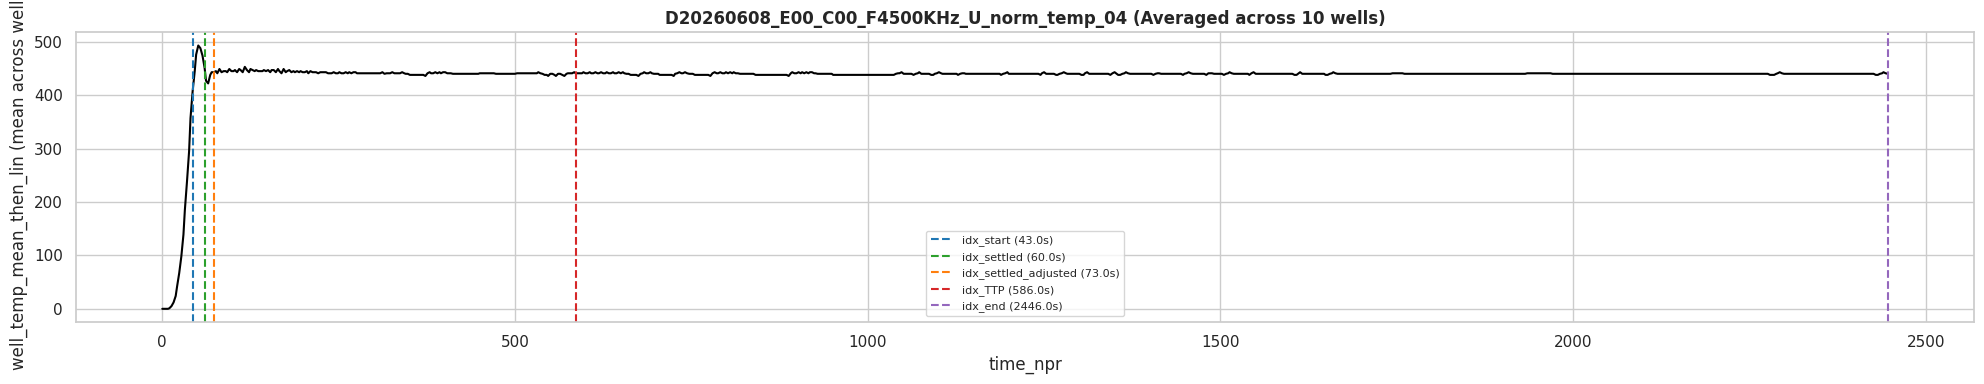

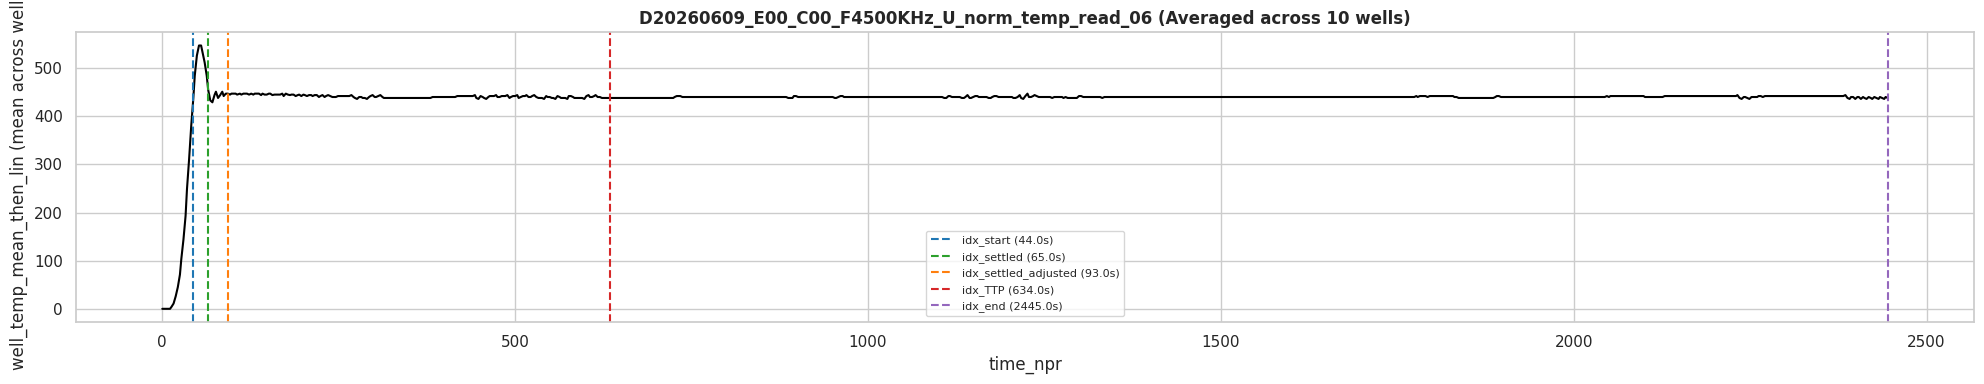

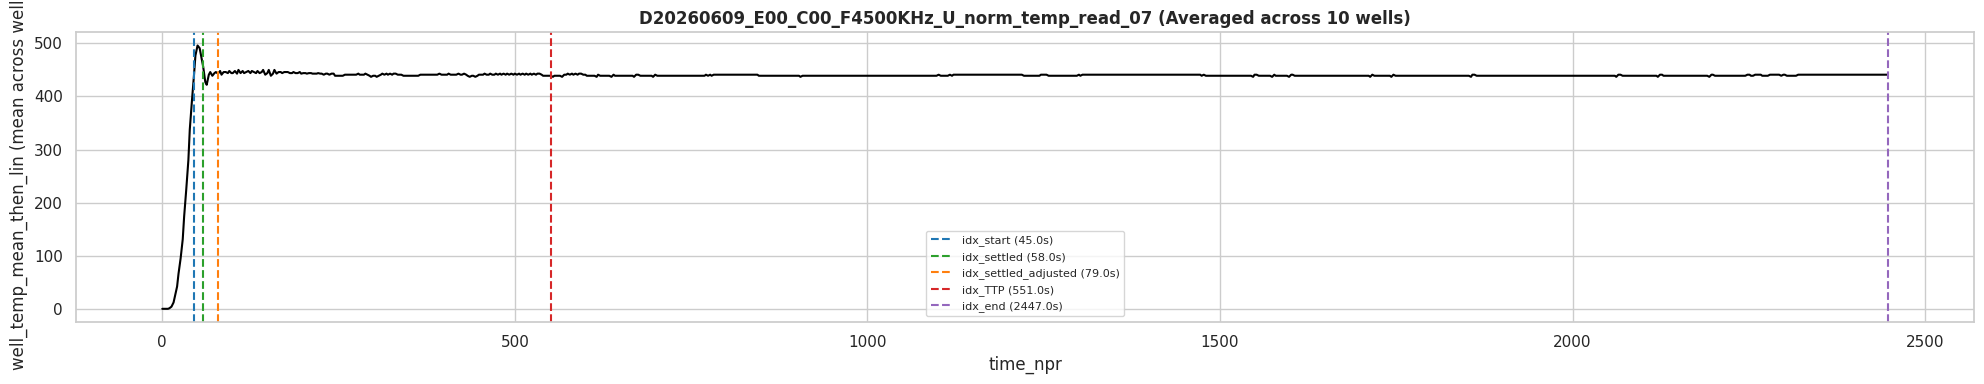

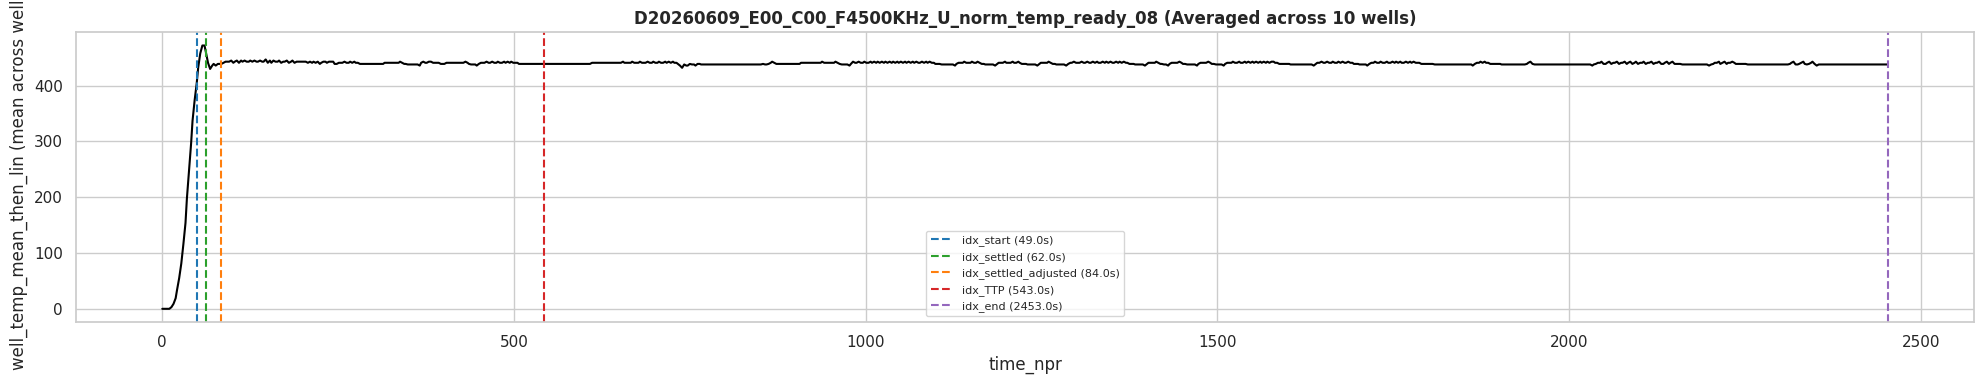

In [133]:
sequence = ["idx_start", "idx_settled", "idx_settled_adjusted", "idx_TTP", "idx_end"]
colors = {
    "idx_start": "tab:blue", "idx_settled": "tab:green", "idx_settled_adjusted": "tab:orange",
    "idx_TTP": "tab:red", "idx_end": "tab:purple",
}

for exp_name in summary_df["Experiment"].unique():
    wells = loaded_exp_data[exp_name][0].wells_list

    x = wells[0].time_npr  # same across all wells in this experiment
    y = np.mean([w.well_temp_mean_then_lin for w in wells], axis=0)

    fig, ax = plt.subplots(figsize=(20, 4))
    ax.plot(x, y, color="black", lw=1.5)

    row = summary_df[summary_df["Experiment"] == exp_name].iloc[0]
    for key in sequence:
        idx = row[key]
        if pd.isna(idx):
            continue
        idx = int(idx)
        t = row[f"t_{key}"]
        if 0 <= idx < len(x):
            ax.axvline(x[idx], color=colors[key], linestyle="--", lw=1.5,
                       label=f"{key} ({t:.1f}s)")

    ax.set_title(f"{exp_name} (Averaged across {len(wells)} wells)", fontsize=12, fontweight="bold")
    ax.set_xlabel("time_npr")
    ax.set_ylabel("well_temp_mean_then_lin (mean across wells)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [135]:
summary_df[["Experiment", "idx_start", "idx_settled", "idx_settled_adjusted", "idx_TTP", "idx_end"]]

,Experiment,idx_start,idx_settled,idx_settled_adjusted,idx_TTP,idx_end
0,D20260608_E00_C00_F4500KHz_U_norm_temp_04,16,22,27,213.258881,884
1,D20260609_E00_C00_F4500KHz_U_norm_temp_read_06,16,24,34,232.809714,896
2,D20260609_E00_C00_F4500KHz_U_norm_temp_read_07,17,22,30,206.367520,912
3,D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08,18,23,31,199.617674,899


In [138]:
summary_df["t_idx_TTP_from_settled_adjusted"] = summary_df["t_idx_TTP"] - summary_df["t_idx_settled_adjusted"]

summary_df[["Experiment", "t_idx_start", "t_idx_settled", "t_idx_settled_adjusted", "t_idx_TTP", "t_idx_end", "t_idx_TTP_from_settled_adjusted"]]

,Experiment,t_idx_start,t_idx_settled,t_idx_settled_adjusted,t_idx_TTP,t_idx_end,t_idx_TTP_from_settled_adjusted
0,D20260608_E00_C00_F4500KHz_U_norm_temp_04,43.0,60.0,73.0,586.0,2446.0,513.0
1,D20260609_E00_C00_F4500KHz_U_norm_temp_read_06,44.0,65.0,93.0,634.0,2445.0,541.0
2,D20260609_E00_C00_F4500KHz_U_norm_temp_read_07,45.0,58.0,79.0,551.0,2447.0,472.0
3,D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08,49.0,62.0,84.0,543.0,2453.0,459.0


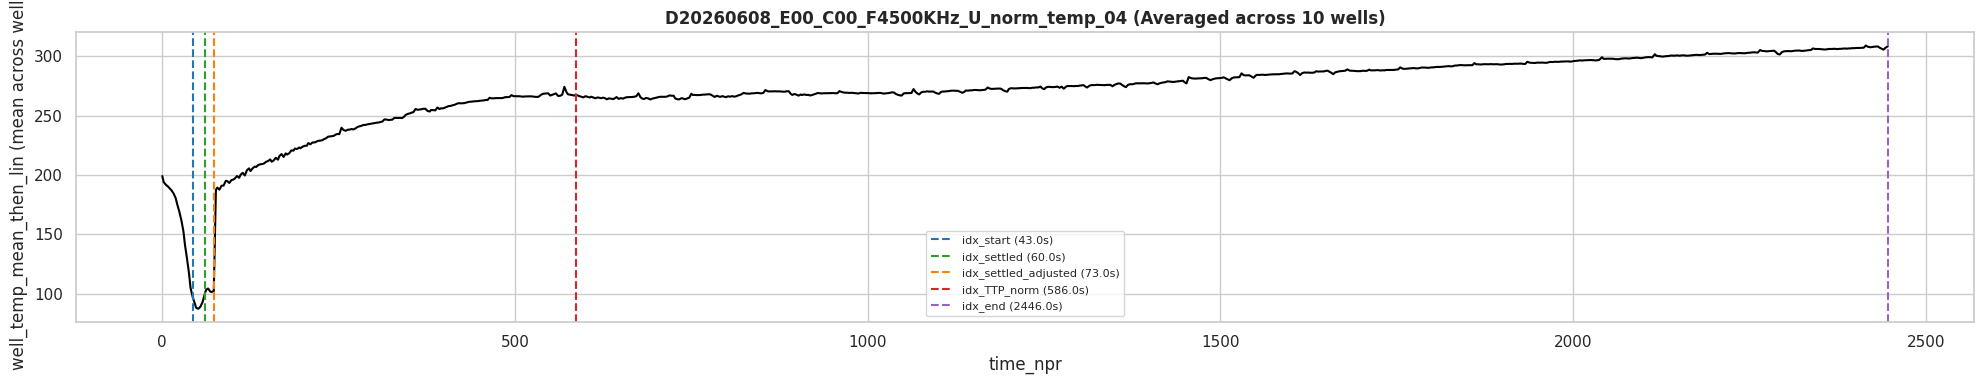

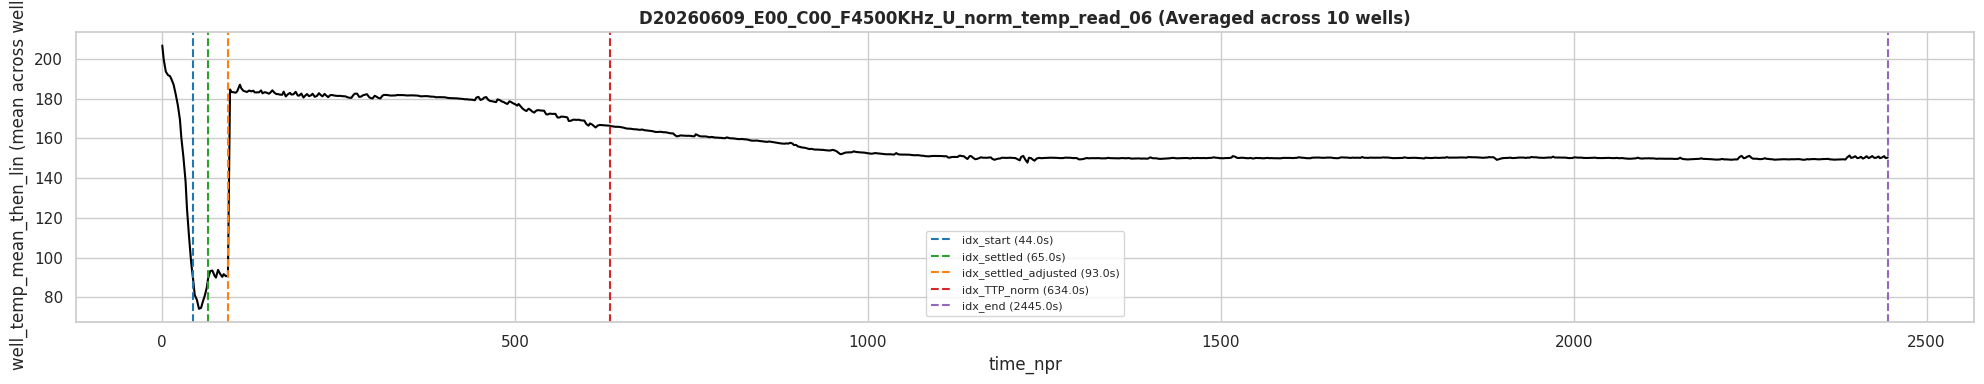

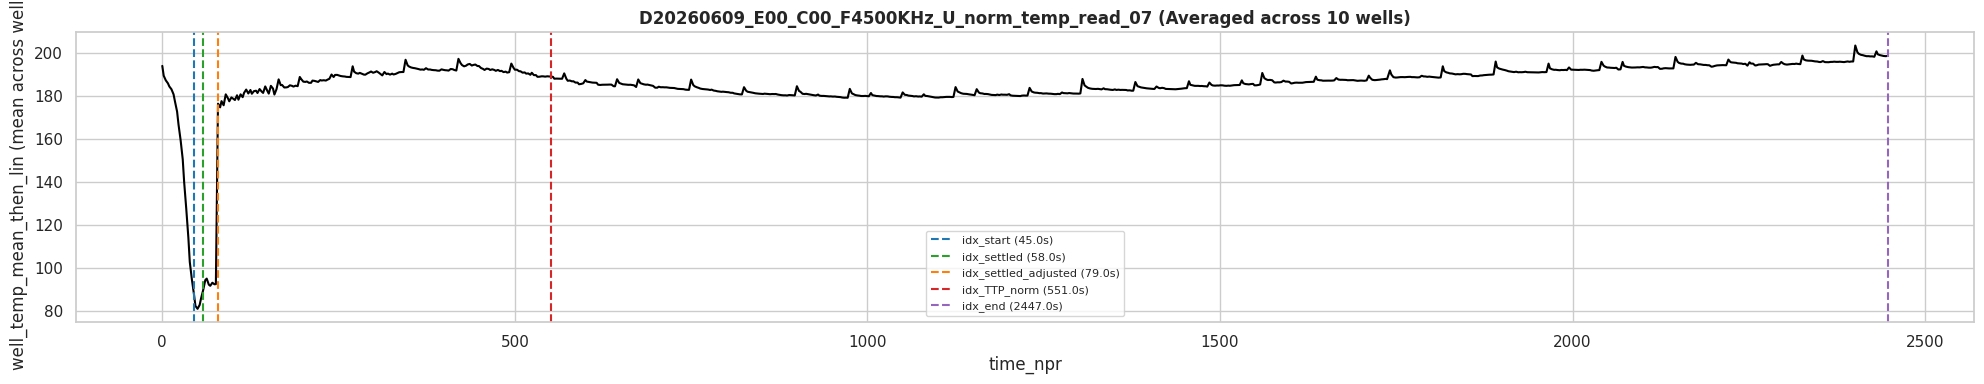

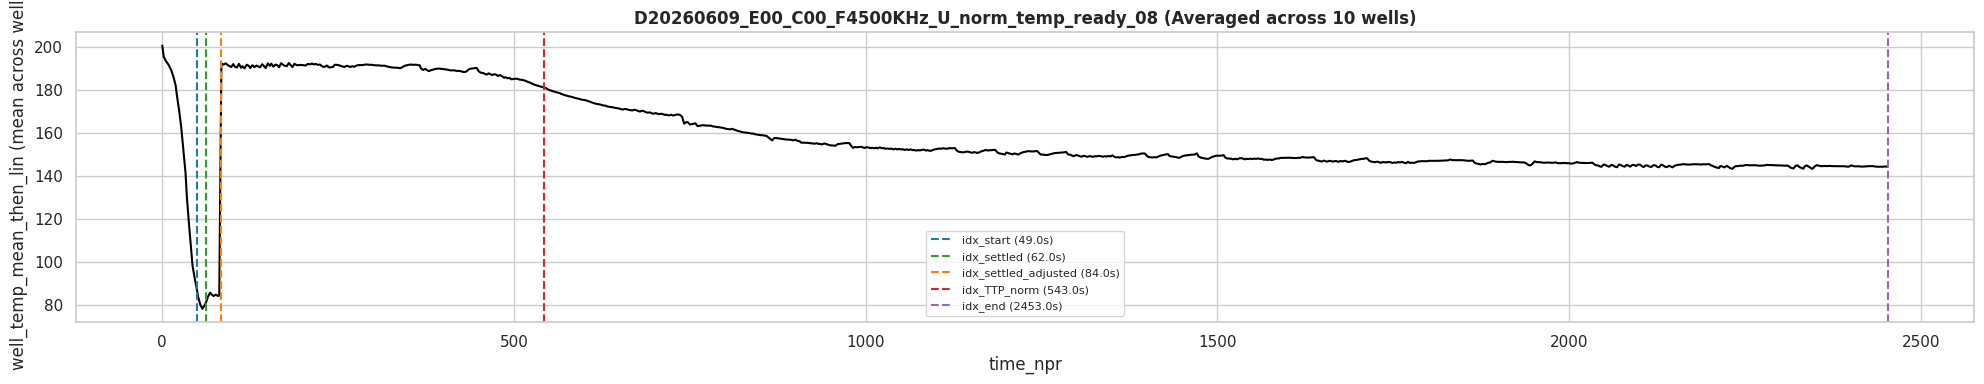

In [115]:
for exp_name in summary_df["Experiment"].unique():
    wells = loaded_exp_data[exp_name][0].wells_list

    x = wells[0].time_npr  # same across all wells in this experiment
    y = np.mean([np.mean(w.well_2d_npr, axis=1) for w in wells], axis=0)

    fig, ax = plt.subplots(figsize=(20, 4))
    ax.plot(x, y, color="black", lw=1.5)

    row = summary_df[summary_df["Experiment"] == exp_name].iloc[0]
    for key in sequence:
        idx = row[key]
        if pd.isna(idx):
            continue
        idx = int(idx)
        t = row[f"t_{key}"]
        if 0 <= idx < len(x):
            ax.axvline(x[idx], color=colors[key], linestyle="--", lw=1.5,
                       label=f"{key} ({t:.1f}s)")

    ax.set_title(f"{exp_name} (Averaged across {len(wells)} wells)", fontsize=12, fontweight="bold")
    ax.set_xlabel("time_npr")
    ax.set_ylabel("well_temp_mean_then_lin (mean across wells)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
